# Mutual Fund Analytics - Performance Analytics

## Internship Project Day 4

Prepared by: Swarangi Kadam

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nav = pd.read_csv("data/raw/02_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [2]:
nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


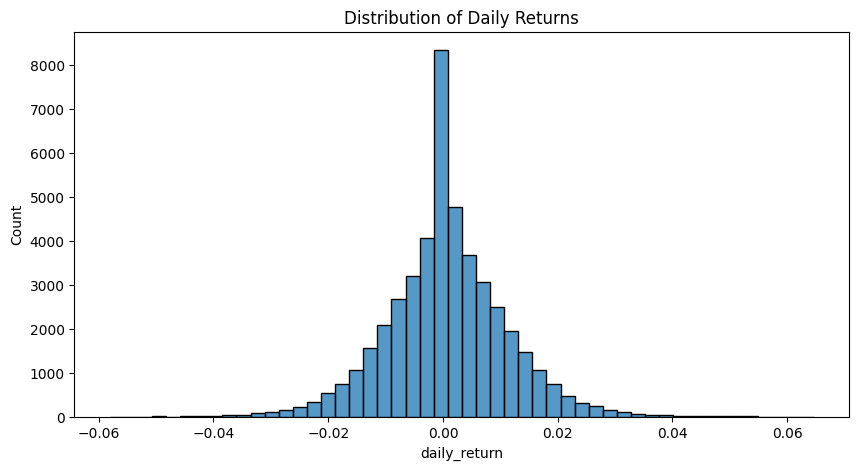

In [3]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50
)

plt.title("Distribution of Daily Returns")

plt.show()

### Finding 1
Daily returns are centered near zero and follow an approximately normal distribution with occasional extreme movements.

In [4]:
cagr_results = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund]

    start_nav = temp.iloc[0]["nav"]
    end_nav = temp.iloc[-1]["nav"]

    years = (
        (temp.iloc[-1]["date"] -
         temp.iloc[0]["date"]).days
    ) / 365

    cagr = (
        (end_nav/start_nav)**(1/years)
    ) - 1

    cagr_results.append(
        [fund,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=["amfi_code","cagr"]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [6]:
rf = 0.065

sharpe_results = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"]==fund
    ]["daily_return"].dropna()

    annual_return = returns.mean()*252

    annual_vol = returns.std()*np.sqrt(252)

    sharpe = (
        annual_return-rf
    ) / annual_vol

    sharpe_results.append(
        [fund,sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=["amfi_code","sharpe_ratio"]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [8]:
sortino_results = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"]==fund
    ]["daily_return"].dropna()

    downside = returns[
        returns < 0
    ]

    annual_return = returns.mean()*252

    downside_std = (
        downside.std()*np.sqrt(252)
    )

    sortino = (
        annual_return-rf
    ) / downside_std

    sortino_results.append(
        [fund,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=["amfi_code","sortino_ratio"]
)

In [9]:
benchmark = pd.read_csv(
    "data/raw/10_benchmark_indices.csv"
)

print(benchmark.columns.tolist())
print(benchmark.head())

['date', 'index_name', 'close_value']
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15


In [10]:
from scipy.stats import linregress

benchmark = pd.read_csv(
    "data/raw/10_benchmark_indices.csv"
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

alpha_beta_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ][["date","daily_return"]]

    merged = pd.merge(
        fund_data,
        nifty100[["date","benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 30:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta_results.append(
            [fund, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [12]:
alpha_beta_df.to_csv(
    "alpha_beta.csv",
    index=False
)

In [13]:
print(alpha_beta_df.shape)
alpha_beta_df.head()

(40, 3)


,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [14]:
drawdown_results = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund].copy()

    temp["running_max"] = temp["nav"].cummax()

    temp["drawdown"] = (
        temp["nav"] / temp["running_max"]
    ) - 1

    max_dd = temp["drawdown"].min()

    drawdown_results.append(
        [fund, max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=["amfi_code","max_drawdown"]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [15]:
scorecard = cagr_df.copy()

scorecard = scorecard.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df,
    on="amfi_code"
)

scorecard["return_rank"] = scorecard["cagr"].rank(ascending=False)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(ascending=False)

scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False)

scorecard["dd_rank"] = scorecard["max_drawdown"].rank(ascending=False)

scorecard["fund_score"] = (
    0.30*scorecard["return_rank"]
    + 0.25*scorecard["sharpe_rank"]
    + 0.20*scorecard["alpha_rank"]
    + 0.25*scorecard["dd_rank"]
)

scorecard = scorecard.sort_values(
    "fund_score"
)

scorecard.head()

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,dd_rank,fund_score
34,148567,0.309499,1.448291,0.269838,0.023684,-0.112657,5.0,1.0,7.0,8.0,5.15
30,120843,0.308833,1.306744,0.273305,-0.022830,-0.129740,6.0,2.0,5.0,13.0,6.55
36,148569,0.319245,1.234930,0.282704,0.018134,-0.163967,4.0,3.0,4.0,21.0,8.00
25,120505,0.328016,1.180101,0.292636,0.000549,-0.181885,1.0,5.0,3.0,25.0,8.40
2,100033,0.300997,1.093699,0.271954,0.005104,-0.162172,7.0,7.0,6.0,20.0,10.05


In [16]:
scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

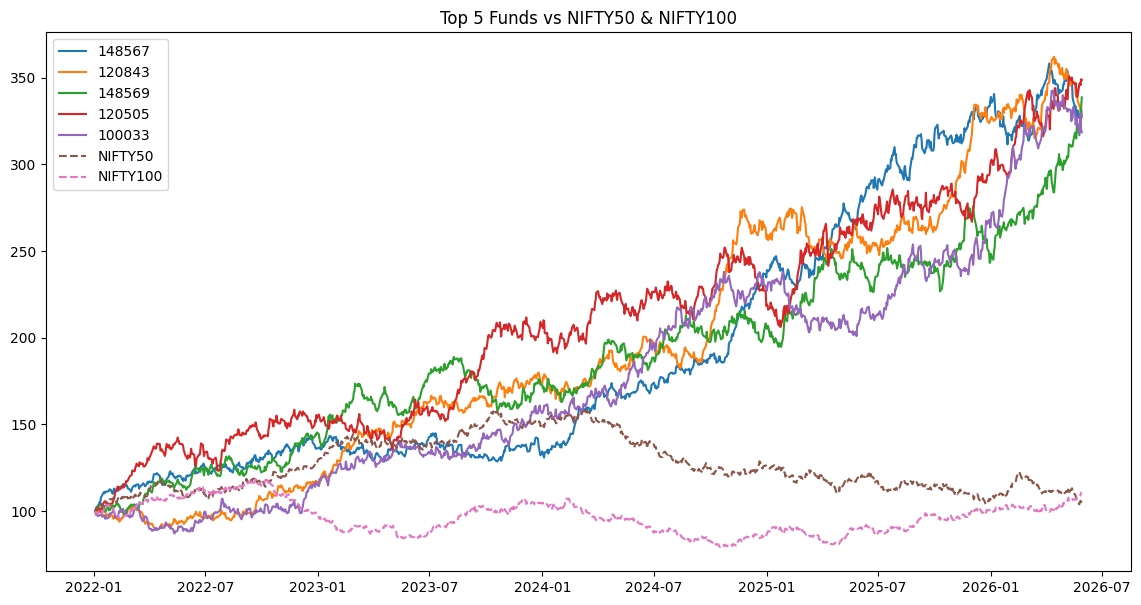

In [17]:
import matplotlib.pyplot as plt

top5 = scorecard["amfi_code"].head(5).tolist()

plt.figure(figsize=(14,7))

for fund in top5:

    temp = nav[
        nav["amfi_code"] == fund
    ]

    normalized = (
        temp["nav"] /
        temp["nav"].iloc[0]
    ) * 100

    plt.plot(
        temp["date"],
        normalized,
        label=str(fund)
    )

for index_name in ["NIFTY50","NIFTY100"]:

    idx = benchmark[
        benchmark["index_name"] == index_name
    ].copy()

    normalized = (
        idx["close_value"] /
        idx["close_value"].iloc[0]
    ) * 100

    plt.plot(
        pd.to_datetime(idx["date"]),
        normalized,
        linestyle="--",
        label=index_name
    )

plt.title(
    "Top 5 Funds vs NIFTY50 & NIFTY100"
)

plt.legend()

plt.savefig(
    "benchmark_comparison_chart.png",
    bbox_inches="tight"
)

plt.show()